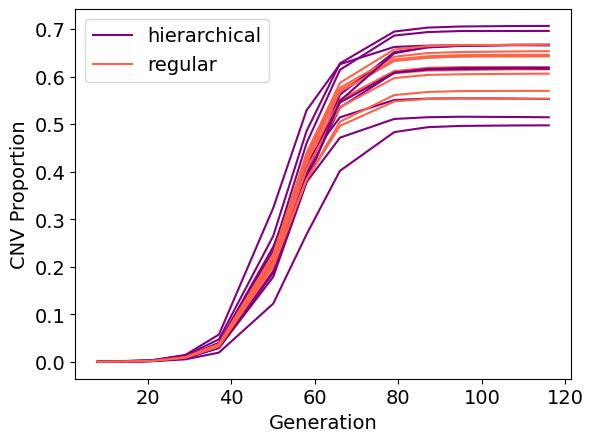

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot, kdeplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, wrapper_hierarchical, WF
import warnings
warnings.simplefilter('ignore', FutureWarning)

generation = np.array(pd.read_csv('empirical_data/Chuong_116_gens.txt').columns.astype('int'))

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

th = torch.tensor([-0.74,-4.84,-4.32], dtype=torch.float32)
X = wrapper(WF, parameters=th, reps=10) # LTRΔ MAP in paper
X_emp = torch.from_numpy(np.array(pd.read_csv('empirical_data/ltr.csv', index_col=0)))
X_h = wrapper_hierarchical(WF, parameters=th, reps=10)
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X_h[i], color='purple', label='hierarchical' if i==0 else '')
    plt.plot(generation,X[i], color='tomato', label='regular' if i==0 else '')
    # plt.plot(generation,X_emp[i], color='grey', label='empirical' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')
plt.legend()

In [2]:
%%time
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl', 'rb'))
epsilon = -150


Xs = torch.tensor(X)
op = CollectivePosterior(prior, Xs, posterior_chuong, 1, epsilon, n_eval=10000)

print(op.get_log_C())
# est = op.sample(1000).mean(0)
# est

<timed exec>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


tensor(11.1336)
CPU times: user 1min 18s, sys: 1.58 s, total: 1min 19s
Wall time: 1.87 s


In [4]:
est = op.sample_multimodal(500, k=10).mean(0)
est

Rejection Sampling: 11it [00:08,  1.35it/s]                       
Sampling: 100%|██████████| 500/500 [00:19<00:00, 25.14it/s]


tensor([-0.7327, -4.9190, -4.3976])

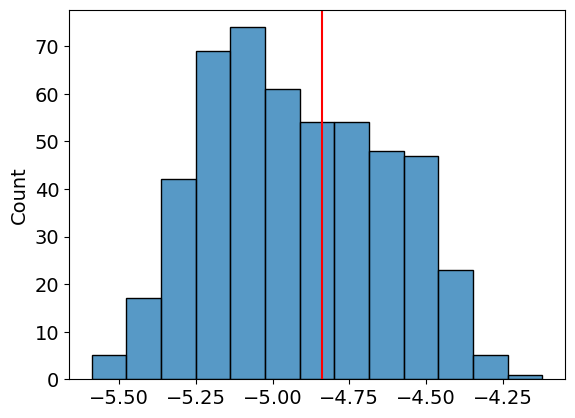

In [5]:
from seaborn import histplot, kdeplot
histplot(op.samples[:,1])
plt.axvline(th[1], color='red')

Text(0, 0.5, '')

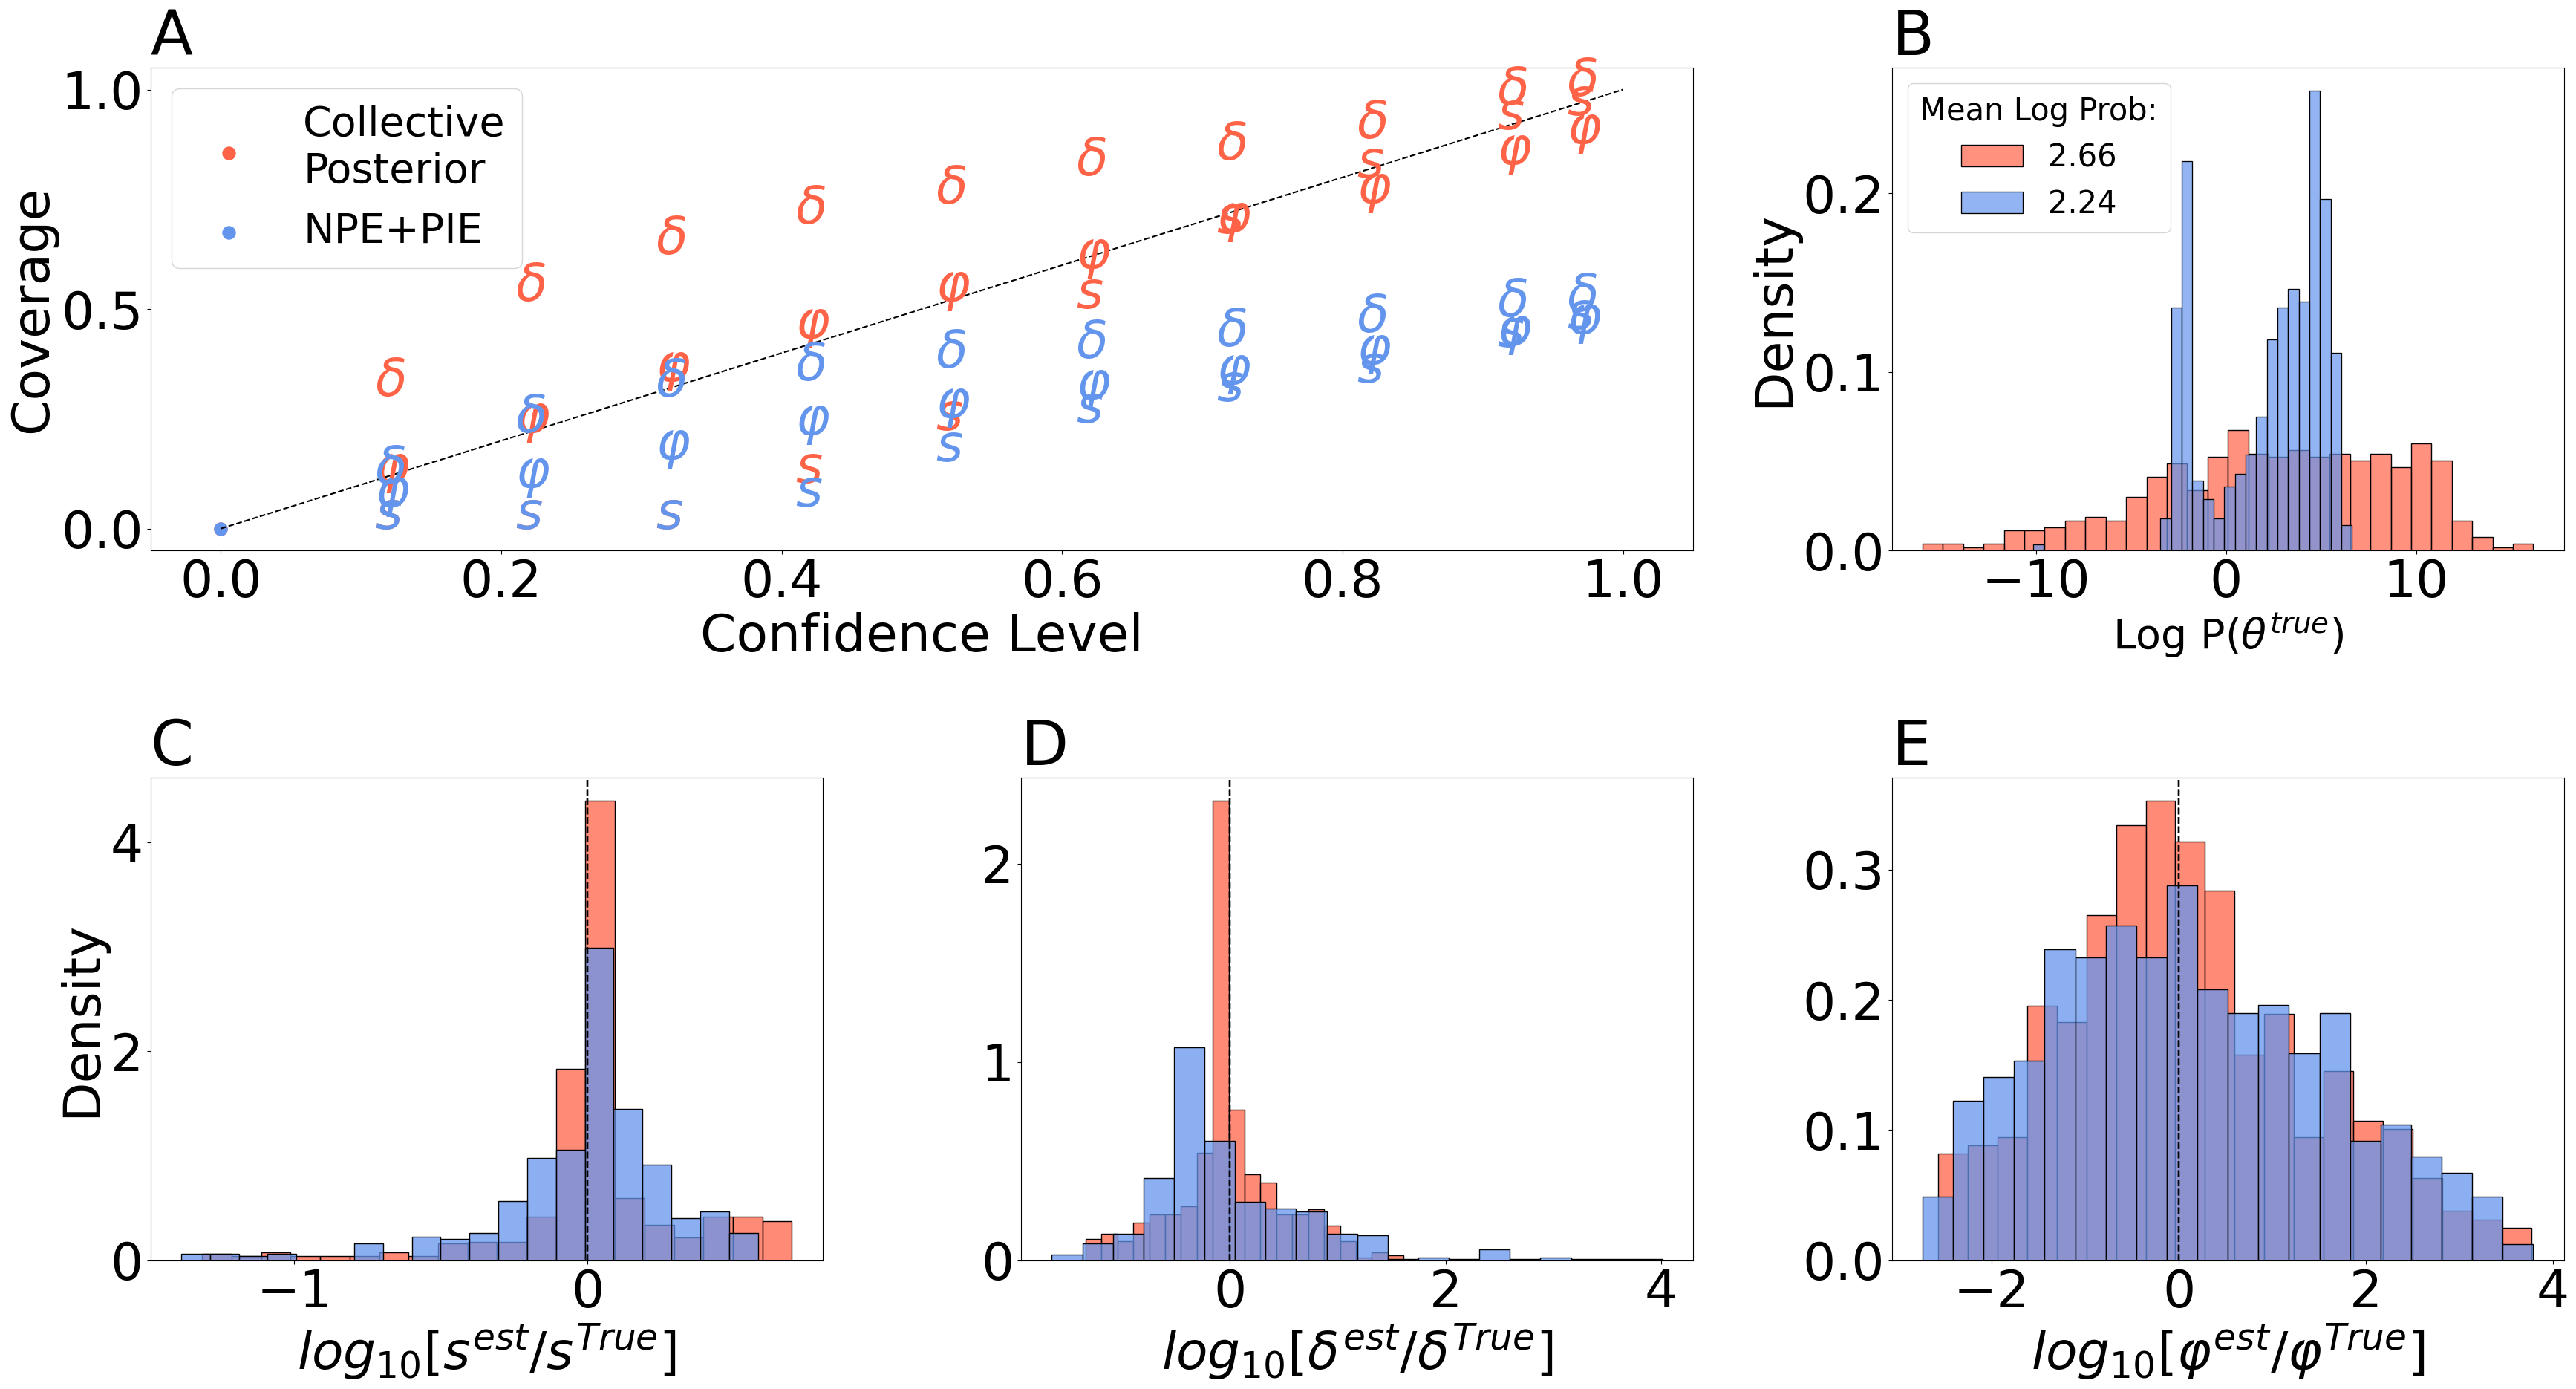

In [5]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=20, label=label, hatch=hatch)
        # kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=True):
    param_names = ['$s$', '$\\delta$', '$\\varphi$']
    adjust=0.01 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, color=color)
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=400)
    ax.scatter(0,0,s=150, label=label, color=color)
        
def tensor_cdf(tensor):
    """
    Given a 1D torch tensor or numpy array, returns (sorted_values, cdf_values) for plotting.
    """
    if isinstance(tensor, torch.Tensor):
        arr = tensor.detach().cpu().numpy().flatten()
    else:
        arr = np.asarray(tensor).flatten()
    sorted_vals = np.sort(arr)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    return sorted_vals, cdf

def plot_covs_cdf(ax, covs, color, label):
    """
    Plot the CDF of each column in covs (DataFrame or tensor) on the given axis.
    """
    param_names = ['$log U$', '$\\alpha$', '$log \\beta$']
    if hasattr(covs, 'columns'):
        columns = covs.columns
    else:
        columns = range(covs.shape[1])
    for i, p in enumerate(columns):
        vec = covs[p] if hasattr(covs, 'columns') else covs[:,i]
        sorted_vals, cdf = tensor_cdf(vec)
        ax.plot(sorted_vals, cdf, label=param_names[i] if i < len(param_names) else str(p), color=color)
    ax.legend()
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.set_title(label)

def plot_log_probs(ax, log_probs, color, label):
    histplot(log_probs, ax=ax, label=label, color=color, stat='density', bins=30, alpha=0.7)
    ax.legend(title='Mean Log Prob:', fontsize=30, title_fontsize=30, loc='upper left')
    ax.set_xlabel('Log P($\\theta^{true}$)', fontsize=40)
    ax.set_ylabel('Density')


# A - log probabilites
# B - Coverage plots
# C-E - Accuracy plots
mosaic = '''BBA
            CDE
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('B',loc='left')
ax['B'].set_title('A',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')

# plot log probs in ax A

log_probs_cp = pd.read_csv('tests/logprobs_WF_r.csv', index_col=0, dtype='float').to_numpy().flatten()
plot_log_probs(ax['A'], log_probs_cp, color='tomato', label=round(log_probs_cp.mean(),2))
log_probs_iid = pd.read_csv('tests/logprobs_WF_iid_r.csv', index_col=0, dtype='float').to_numpy().flatten()
plot_log_probs(ax['A'], log_probs_iid, color='cornflowerblue', label=round(log_probs_iid.mean(),2))
ax['A'].set_xlabel('Log P($\\theta^{true}$)')
ax['A'].set_ylabel('Density')

# Coverage plots in ax B
ax['B'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_WF_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['B'], covs=covs_,label='Collective\nPosterior',color='tomato')
covs_iid = pd.read_csv(f'tests/covs_old_WF_iid_r.csv', index_col=0, dtype='float')/2
plot_covs_old(ax=ax['B'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue')
ax['B'].set_xlabel('Confidence Level')
ax['B'].set_ylabel('Coverage')
ax['B'].legend(fontsize=40)

# Accuracy plots in ax C-E
n_params=3
ax['C'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['D'].set_xlabel('$log_{10}[\\delta^{est} / {\\delta^{True}}]$')
ax['E'].set_xlabel('$log_{10}[\\varphi^{est} / {\\varphi^{True}}]$')

axx = [ax['C'], ax['D'], ax['E']]

cp_acc = 'tests/accus_WF_r.csv'
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = 'tests/accus_WF_iid_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['D'].set_ylabel('')
ax['E'].set_ylabel('')




Text(0, 0.5, '')

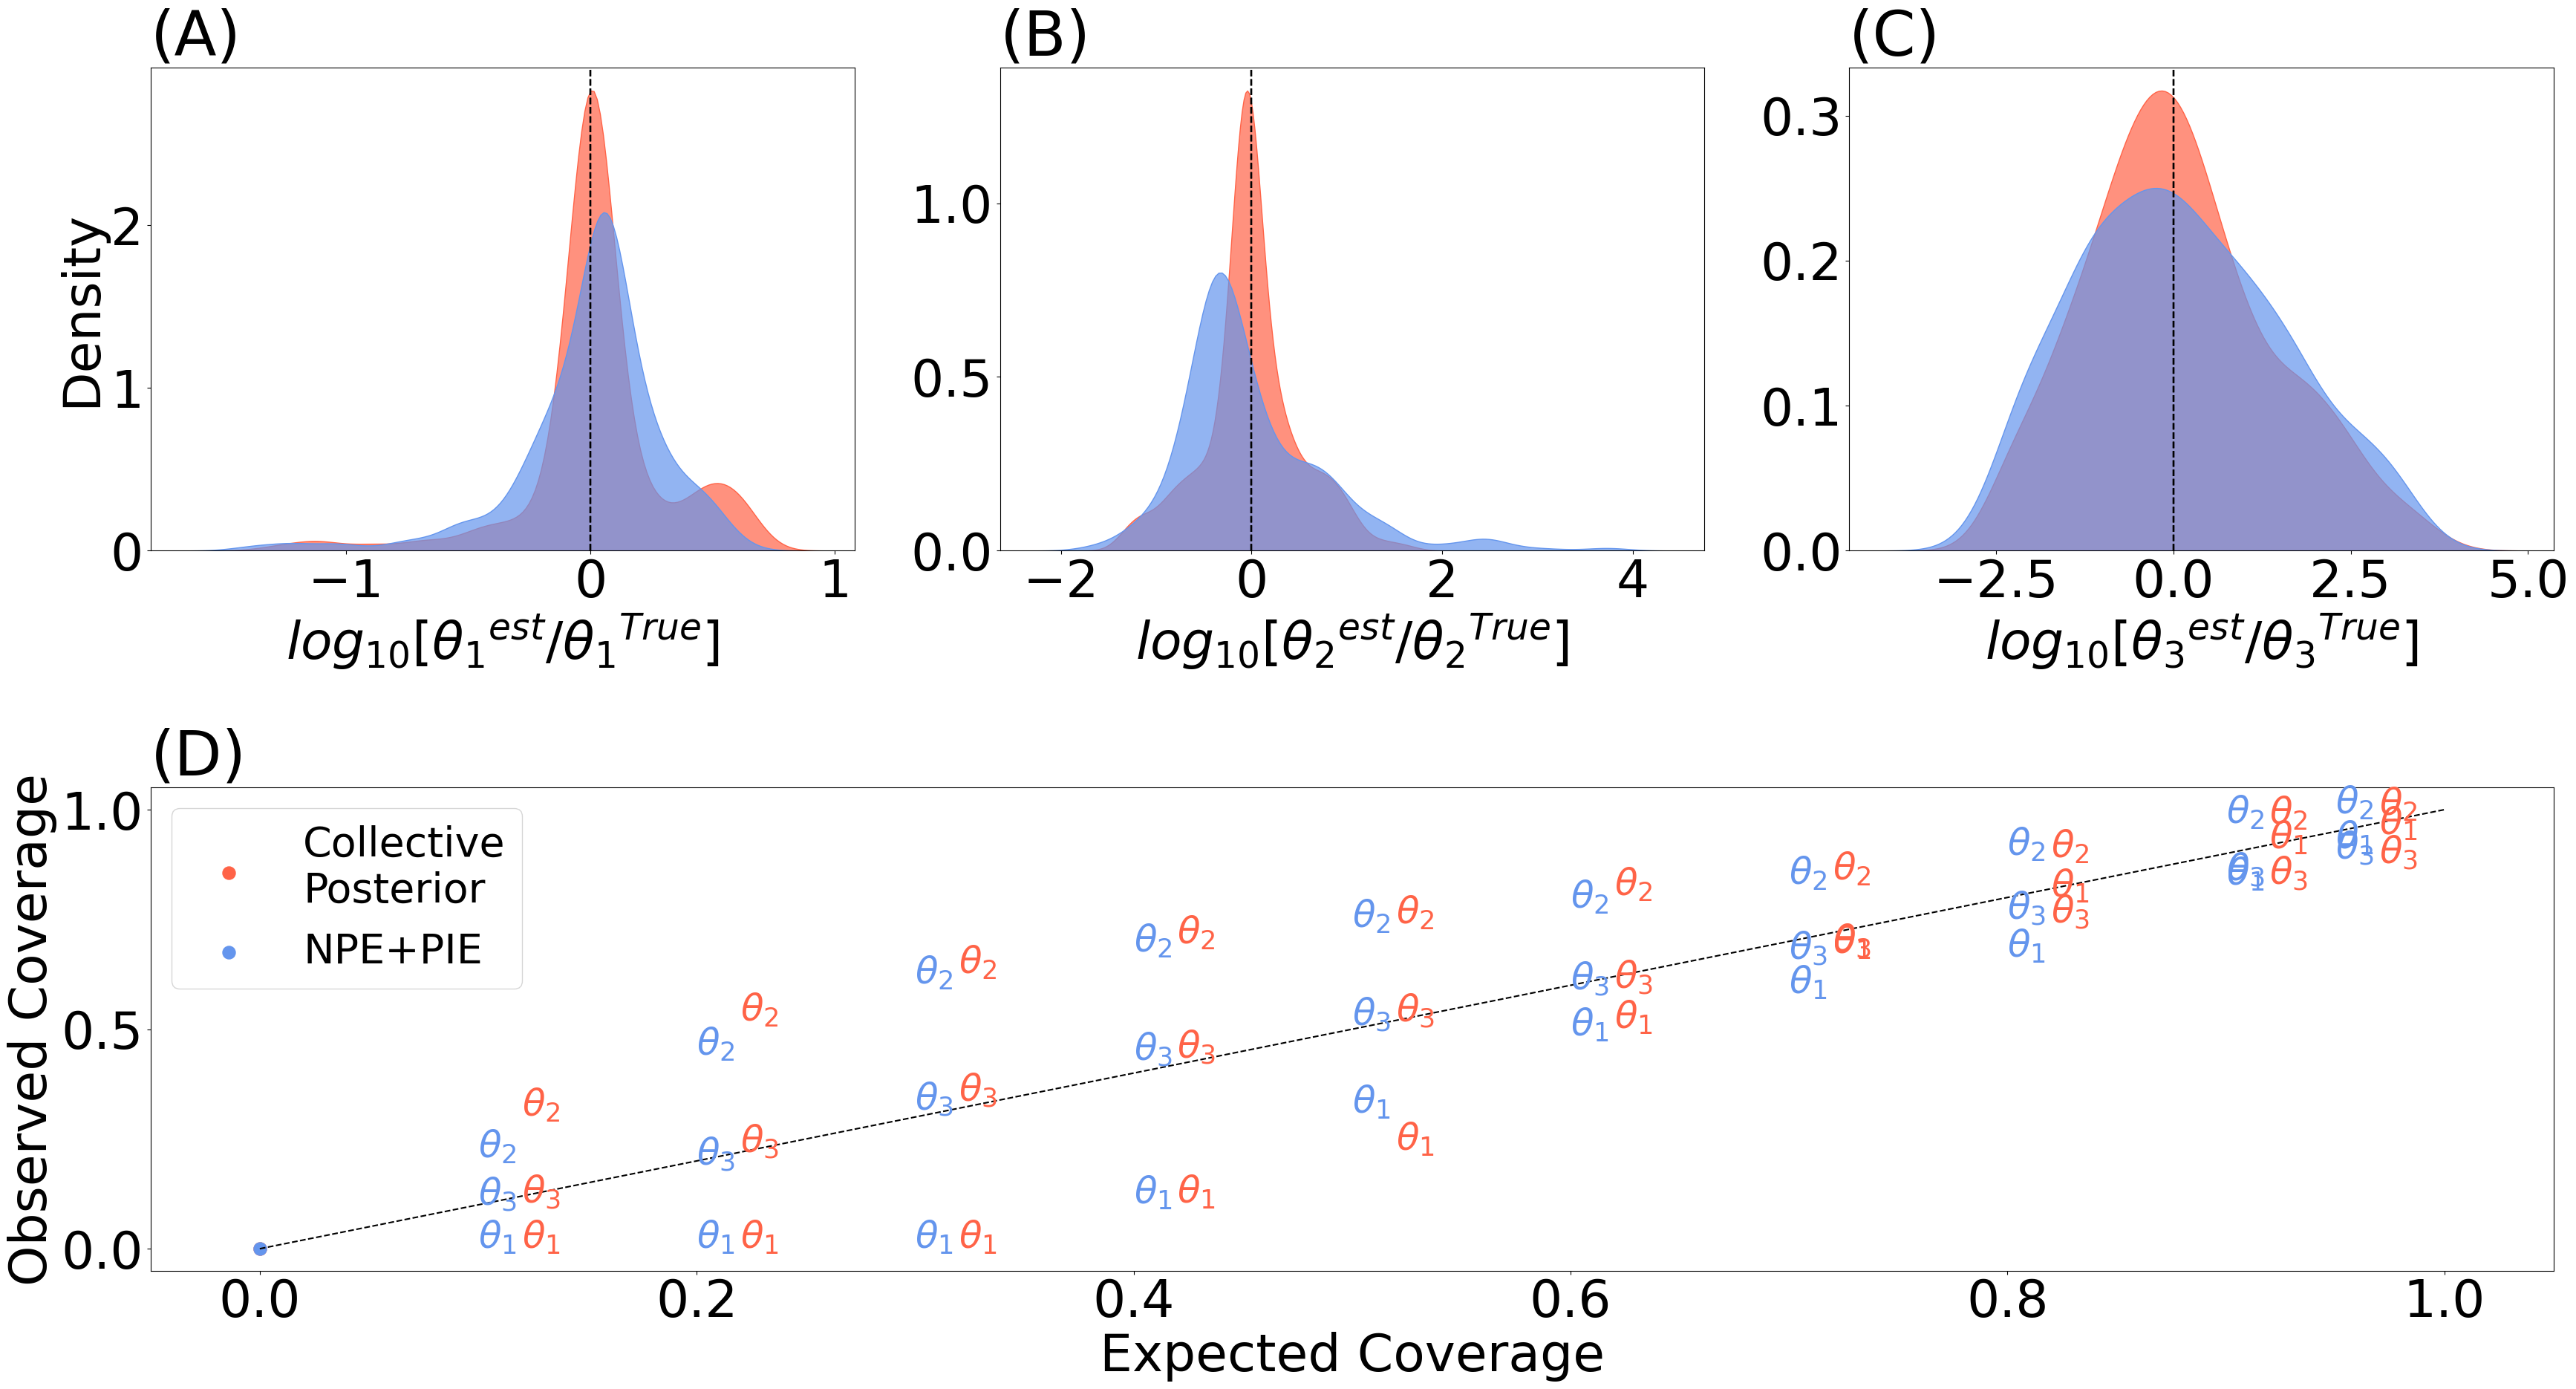

In [16]:
change_font(50)

def plot_accuracy(acc_path, ax, color, label, hatch):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(len(ax)):
        # histplot(res[:,i],ax=ax[i], stat='density', color=color, bins=10, label=label, hatch=hatch)
        kdeplot(res[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
    return


def plot_covs_old(ax, covs, color, label, cp=True):
    param_names = ['$θ_1$', '$θ_2$', '$θ_3$']
    adjust=0.02 if cp else 0
    for i in range(len(covs.columns)):
        p = covs.columns[i]
        word = param_names[i]
        for j in range(1,len(covs[p])):
            # ax.scatter(covs.index[j]+adjust, covs[p].values[j], color=color, s=200)
            ax.text(covs.index[j]+adjust, covs[p].values[j], word, fontsize=36, color=color)
    ax.scatter(0,0,s=150, label=label, color=color)
        
        

mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,20), tight_layout=True)
ax['A'].set_title('(A)',loc='left')
ax['B'].set_title('(B)',loc='left')
ax['C'].set_title('(C)',loc='left')
ax['D'].set_title('(D)',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='', ls='--')
covs_ = pd.read_csv(f'tests/covs_old_WF_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_,label='Collective\nPosterior',color='tomato')
covs_iid = pd.read_csv(f'tests/covs_old_WF_iid_r.csv', index_col=0, dtype='float')
plot_covs_old(ax=ax['D'], covs=covs_iid,label='NPE+PIE',color='cornflowerblue', cp=False)
# covs = pd.read_csv(f'tests/covs_old_WF_m.csv', index_col=0, dtype='float')
# plot_covs_old(ax=ax['D'], covs=covs,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[{θ_1}^{est} / {{θ_1}^{True}}]$')
ax['B'].set_xlabel('$log_{10}[{θ_2}^{est} / {{θ_2}^{True}}]$')
ax['C'].set_xlabel('$log_{10}[{θ_3}^{est} / {{θ_3}^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

# cp_acc_m = 'tests/accus_WF_m.csv'
# plot_accuracy(cp_acc_m, axx, color='maroon', hatch='///', label='')

iid_acc = 'tests/accus_WF_iid_h_r.csv'
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['D'].legend(fontsize=40)
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

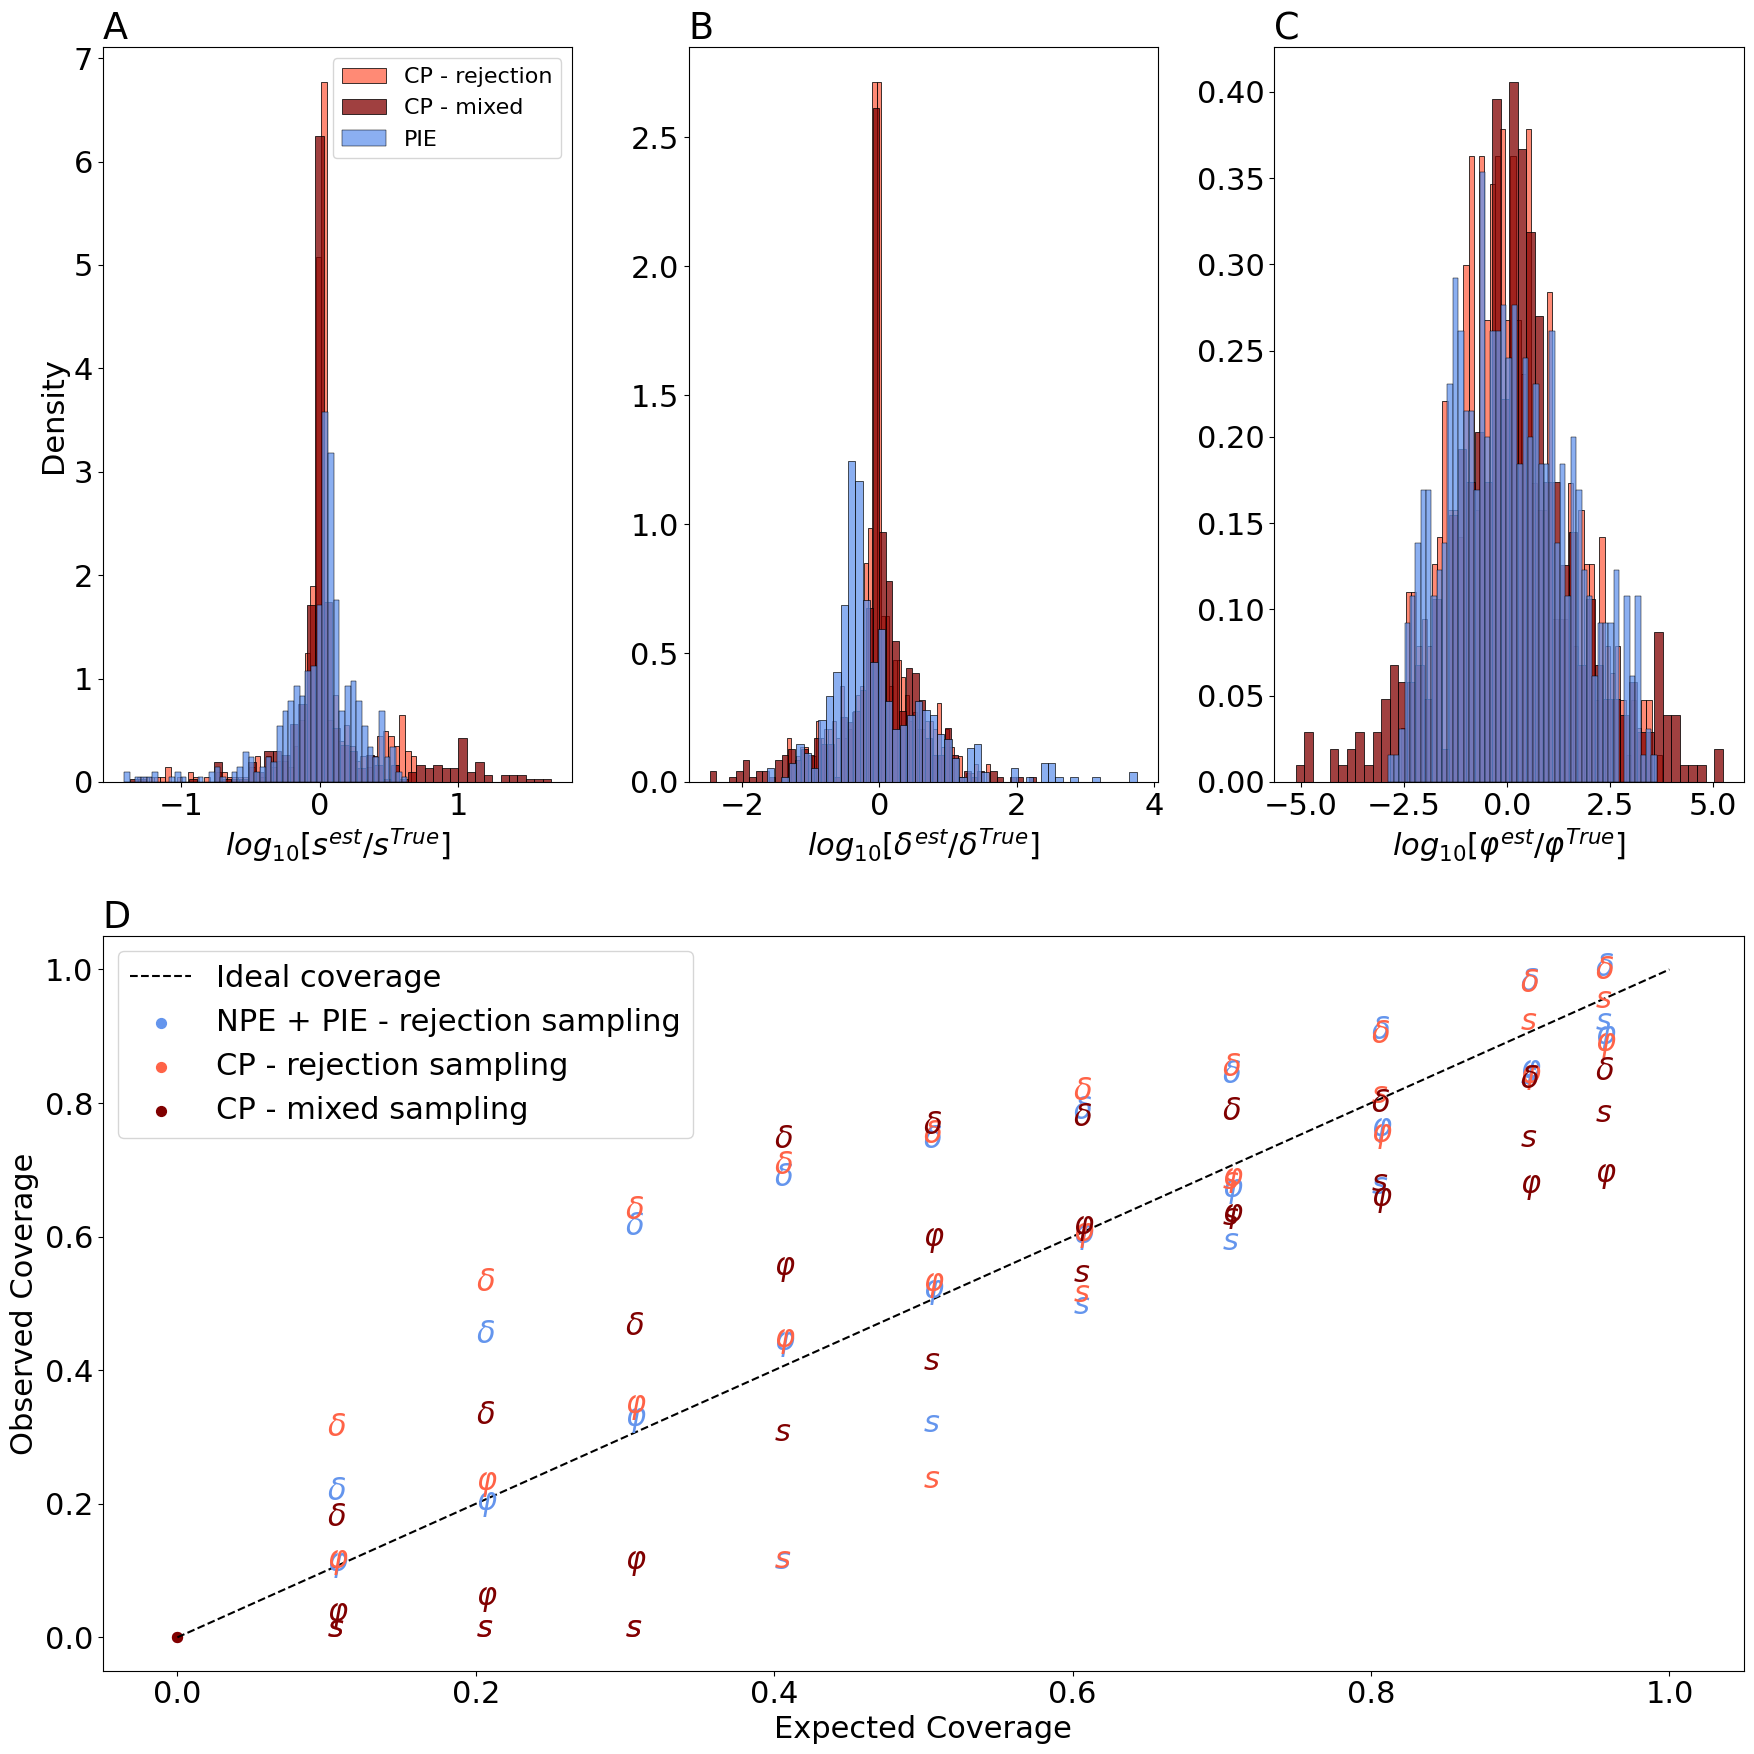

In [13]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE - rejection sampling',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='CP - rejection sampling',color='tomato')
plot_covs_old(ax=ax['D'], covs=covs_cp_m,label='CP - mixed sampling',color='maroon')
ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['D'].legend()



n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='CP - rejection')

cp_m_acc = 'tests/accus_WF_m.csv'
plot_accuracy(cp_m_acc, axx, color='maroon', hatch='', label='CP - mixed')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='PIE')

ax['A'].legend(loc='upper right', fontsize=16)
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



Text(0, 0.5, '')

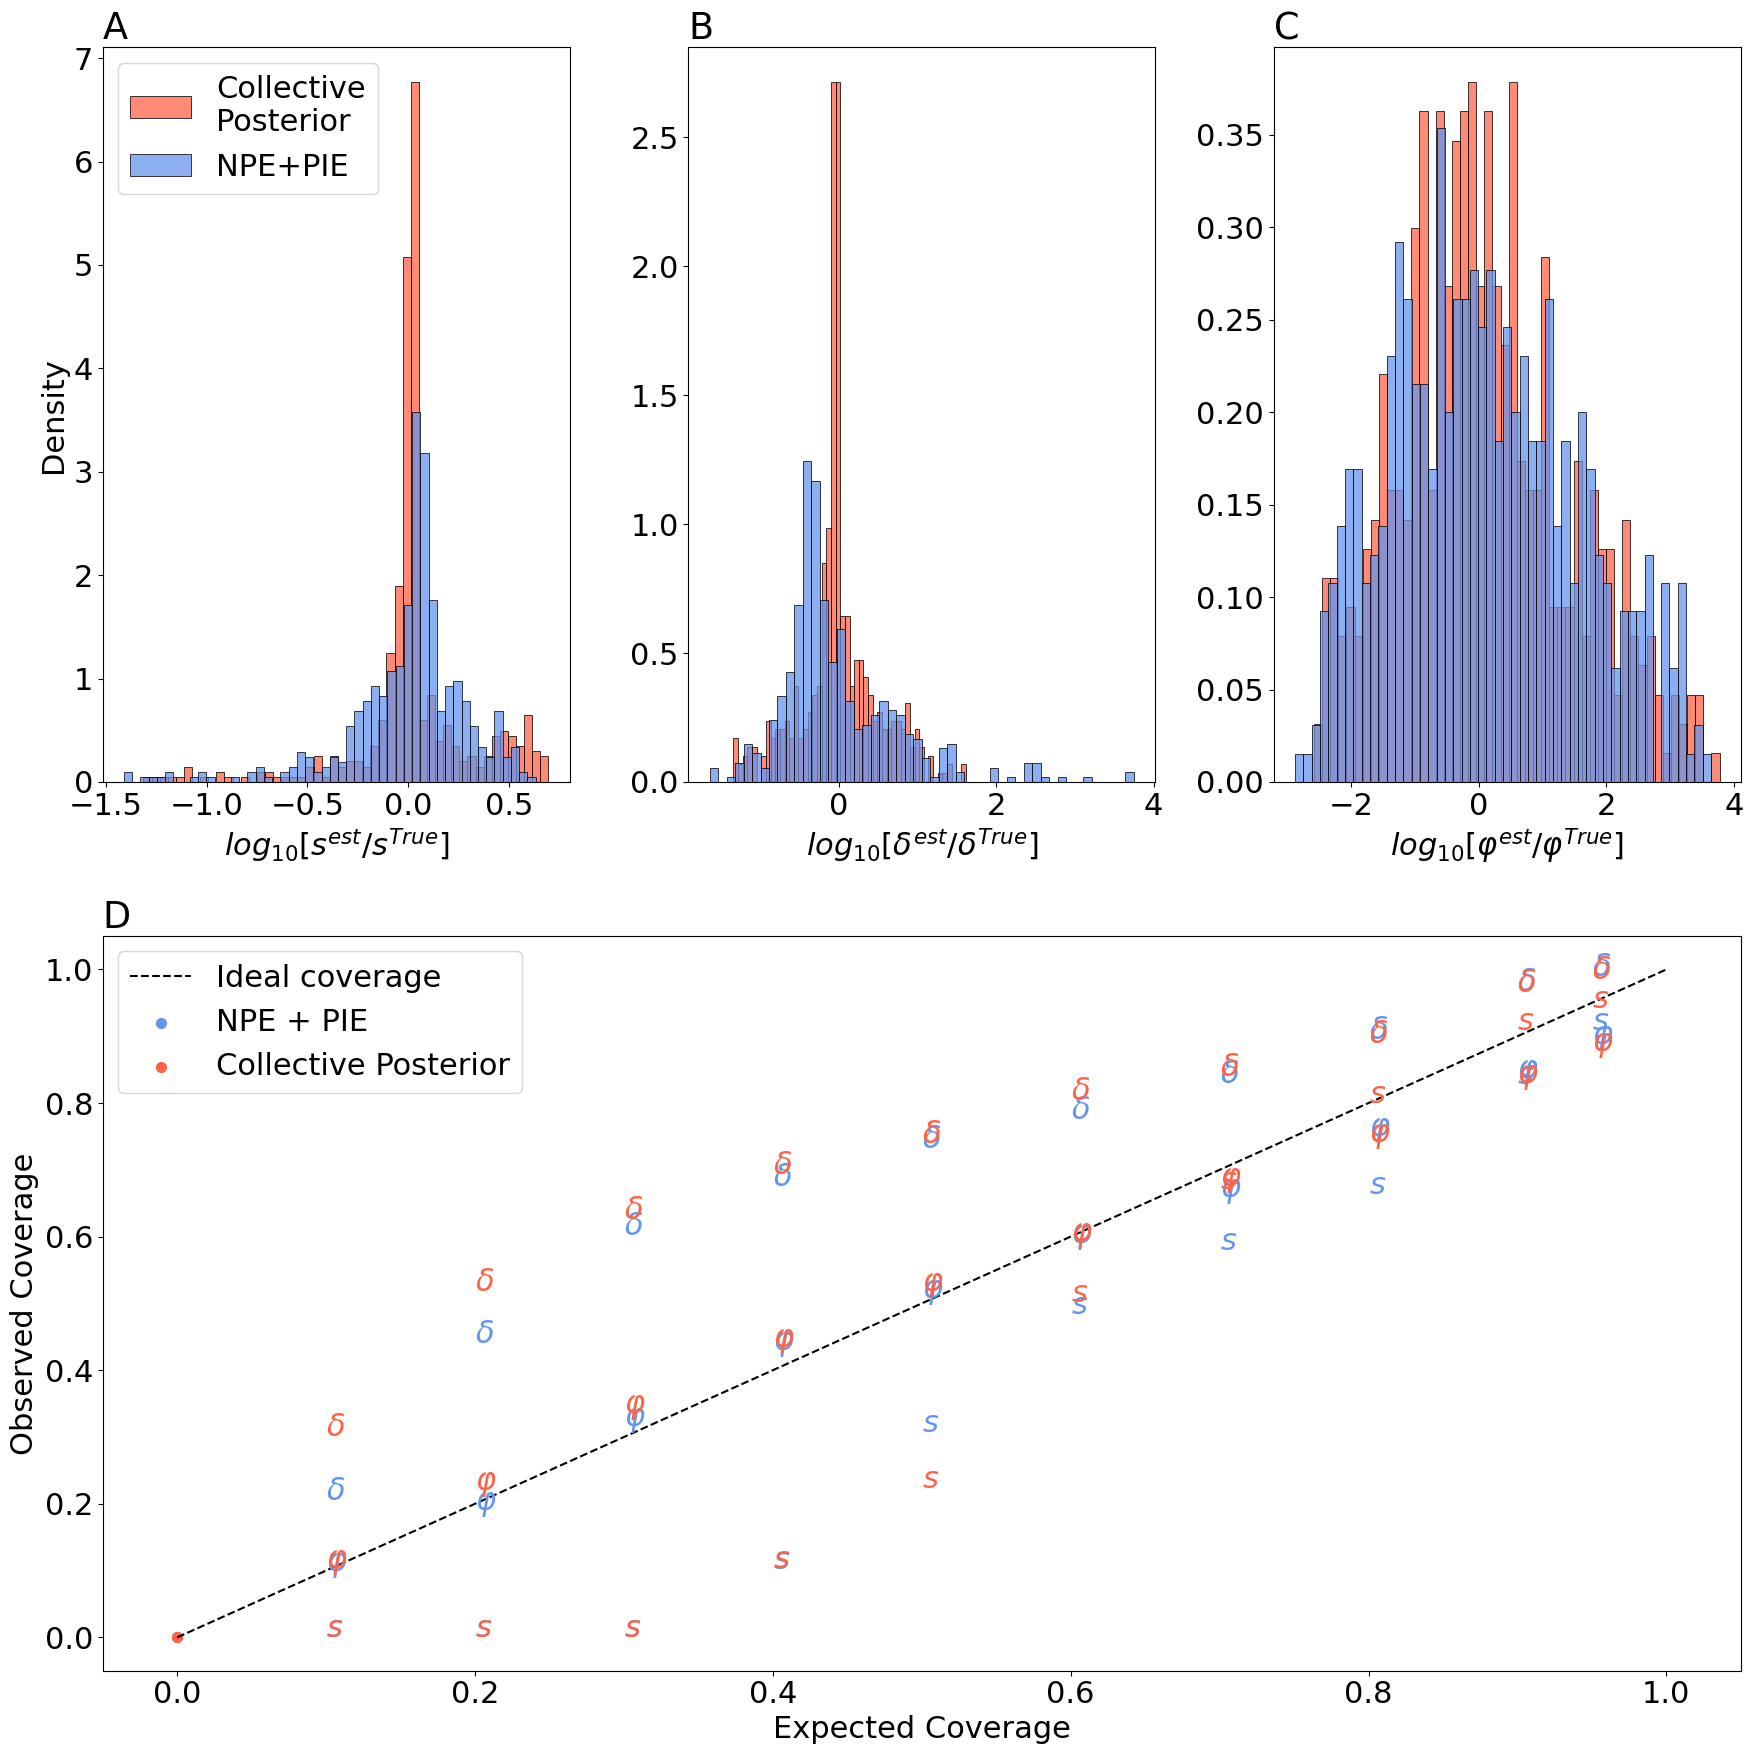

In [15]:
mosaic = '''ABC
            DDD
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(18,18), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')

ax['D'].plot(np.linspace(0,1,100),np.linspace(0,1,100), color='k', label='Ideal coverage', ls='--')
plot_covs_old(ax=ax['D'], covs=covs_cp_iid,label='NPE + PIE',color='cornflowerblue')
plot_covs_old(ax=ax['D'], covs=covs_cp,label='Collective Posterior',color='tomato')


n_params=3
ax['A'].set_xlabel('$log_{10}[s^{est} / {s^{True}}]$')
ax['B'].set_xlabel('$log_{10}[δ^{est} / {δ^{True}}]$')
ax['C'].set_xlabel('$log_{10}[φ^{est} / {φ^{True}}]$')
# fig.supxlabel('')

cp_acc = 'tests/accus_WF_r.csv'
axx = [ax['A'], ax['B'], ax['C']]
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')

plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

ax['D'].set_xlabel('Expected Coverage')
ax['D'].set_ylabel('Observed Coverage')
ax['A'].legend()
ax['D'].legend()
ax['C'].set_ylabel('')
ax['B'].set_ylabel('')

# cp_acc_h = 'tests/accus_WF_h.csv'
# plot_accuracy(cp_acc_h, ax, color='maroon', label='CP - hierarchical', hatch='///')
# plt.legend()



In [29]:
thetas = pd.read_csv('tests/test_thetas.csv', index_col=0)
thetas = torch.from_numpy(np.array(thetas))

cpa = pd.read_csv(cp_acc, index_col=0)
cpa = torch.from_numpy(np.array(cpa))
print(cpa.median(0))
iida = pd.read_csv(iid_acc, index_col=0)
iida = torch.from_numpy(np.array(iida))
print(iida.median(0))

torch.return_types.median(
values=tensor([ 0.0144, -0.0354, -0.0550], dtype=torch.float64),
indices=tensor([119,  11,  95]))
torch.return_types.median(
values=tensor([ 0.0492, -0.2277, -0.0086], dtype=torch.float64),
indices=tensor([ 27,  49, 332]))
